## Checking of Energy Minimization

In [2]:
import os
data_dir = "/home/daneel/gitrepos"
data_dir = os.path.join(data_dir, "gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulations_cg")
os.chdir(data_dir)


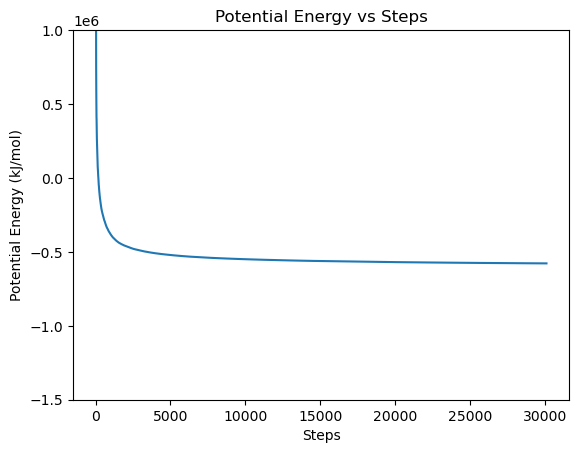

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("simulation_cg_multipeptide/potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

In [6]:
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import MDAnalysis as mda 
from MDAnalysis.analysis import rms 
from multiprocessing import Pool, cpu_count 
from functools import partial 
from tqdm.notebook import tqdm

In [9]:
# ========================================== 
# 1. FILE PATHS & SELECTION CONSTANTS 
# # ========================================== 
complexes = {'multipeptide': {"top_file": "simulation_cg_multipeptide/traj_dry.tpr", "traj_file": "simulation_cg_multipeptide/traj_dry.xtc"},
            'nopeptide': {"top_file": "simulation_cg_nopeptide/traj_dry.tpr", "traj_file": "simulation_cg_nopeptide/traj_dry.xtc"}
            }

multipeptide = complexes['multipeptide']
top_file = multipeptide["top_file"]
traj_file = multipeptide["traj_file"]

# Selections 
pep_sel = "resname ALA ARG ASN ASP CYS GLU GLN GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL" # or "protein" 
memb_sel = "resname DVPE POPG POPE DOPE TOCL" 

# Note: TOCL in MARTINI 3 has PO41 and PO42 beads 
phos_sel = "(resname DVPE POPG POPE DOPE TOCL) and (name PO4 PO41 PO42)"

# Number of parallel workers 
n_jobs = min(8, cpu_count())

# ========================================== # 2. INITIALIZE UNIVERSE & GET SELECTIONS # ========================================== 
u = mda.Universe(top_file, traj_file) 
n_frames = len(u.trajectory) 
times = np.array([ts.time / 1000.0 for ts in u.trajectory]) # Convert ps -> ns

# Split protein into individual peptide AtomGroups 
protein = u.select_atoms(pep_sel) 
peptides = protein.fragments # Automatically splits by molecule connectivity 
num_peptides = len(peptides)

print(f"Loaded trajectory with {n_frames} frames across {times[-1]:.2f} ns.") 
print(f"Detected {num_peptides} individual peptide molecules.")

# Extract reference positions for each peptide (for RMSD calculation) 
# Stored as list of numpy arrays 
u.trajectory[0] 
ref_pep_positions = [pep.positions.copy() for pep in peptides]

# Chunk trajectory frames into slices for multiprocessing Pool 
chunk_size = max(1, n_frames // n_jobs) 
blocks = [slice(i, min(i + chunk_size, n_frames)) for i in range(0, n_frames, chunk_size)]

Loaded trajectory with 24714 frames across 4942.60 ns.
Detected 12 individual peptide molecules.


## Production PP

In [10]:
# ==========================================
# 3. WORKER FUNCTIONS FOR MULTIPROCESSING
# ==========================================

def analyze_peptide_z_block(block_slice, top_f, traj_f, p_sel, m_sel, ph_sel):
    """
    Worker: Calculates z-COM of each peptide, membrane midplane,
    and mean upper/lower phosphate planes for a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    memb_w = u_w.select_atoms(m_sel)
    phos_w = u_w.select_atoms(ph_sel)
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    
    z_peps = np.zeros((n_block, n_peps))
    z_mids = np.zeros(n_block)
    z_p_upper = np.zeros(n_block)
    z_p_lower = np.zeros(n_block)
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        # Membrane COM (midplane z)
        mid_z = memb_w.center_of_mass(unwrap=False)[2] #The membrane is multiple molecules
        z_mids[idx] = mid_z
        
        # Split phosphate beads into upper and lower leaflets based on midplane z
        phos_z = phos_w.positions[:, 2]
        upper_mask = phos_z > mid_z
        lower_mask = phos_z < mid_z
        
        z_p_upper[idx] = phos_z[upper_mask].mean() if np.any(upper_mask) else mid_z
        z_p_lower[idx] = phos_z[lower_mask].mean() if np.any(lower_mask) else mid_z
        
        # Calculate each peptide's z-COM
        for p_idx, pep in enumerate(peptides_w):
            z_peps[idx, p_idx] = pep.center_of_mass(unwrap=True)[2]
            
    u_w.trajectory.close()
    return z_peps, z_mids, z_p_upper, z_p_lower


def analyze_peptide_rmsd_block(block_slice, top_f, traj_f, p_sel, ref_pos_list):
    """
    Worker: Calculates individual peptide RMSDs over a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    rmsd_array = np.zeros((n_block, n_peps))
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        for p_idx, pep in enumerate(peptides_w):
            # Calculate RMSD with rigid-body superposition (translation/rotation alignment)
            # Output in Angstroms
            val = rms.rmsd(pep.positions, ref_pos_list[p_idx], superposition=True)
            rmsd_array[idx, p_idx] = val
            
    u_w.trajectory.close()
    return rmsd_array

In [11]:
# ==========================================
# 4. EXECUTE PARALLEL CALCULATIONS
# ==========================================

# 4A. Calculate RMSD Trajectories
print(f"Computing individual peptide RMSDs on {n_jobs} cores...")
run_rmsd_func = partial(
    analyze_peptide_rmsd_block,
    top_f=top_file, traj_f=traj_file,
    p_sel=pep_sel, ref_pos_list=ref_pep_positions
)

with Pool(n_jobs) as pool:
    rmsd_results = list(tqdm(pool.imap(run_rmsd_func, blocks), total=len(blocks), desc="RMSD Blocks"))
    
rmsd_all = np.vstack(rmsd_results) # Shape: (n_frames, num_peptides)
# Convert to nanometres
rmsd_nm   = rmsd_all   / 10.0
# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_rmsd = pd.DataFrame(rmsd_nm, columns=pep_cols)
df_rmsd.insert(0, "Time_ns", times)
df_rmsd.to_csv("individual_peptide_rmsd.csv", index=False)


Computing individual peptide RMSDs on 8 cores...


RMSD Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

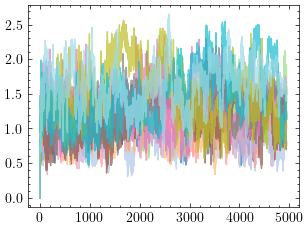

In [12]:
import scienceplots
plt.style.use("science")
# plt.rcParams['text.usetex'] = False
colors = plt.cm.tab20(np.linspace(0, 1, num_peptides))
# --- Plot 2: Individual Peptide RMSD ---
for i in range(num_peptides):
    plt.plot(times, rmsd_nm[:, i], label=f"Pep {i+1}", alpha=0.7, color=colors[i], lw=1.0)

## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

### Get z-COM of peptide

In [13]:
# 4A. Calculate z-COM Trajectories
print(f"Computing z-COM coordinates on {n_jobs} cores...")
run_z_func = partial(
    analyze_peptide_z_block, 
    top_f=top_file, traj_f=traj_file, 
    p_sel=pep_sel, m_sel=memb_sel, ph_sel=phos_sel
)

with Pool(n_jobs) as pool:
    z_results = list(tqdm(pool.imap(run_z_func, blocks), total=len(blocks), desc="z-COM Blocks"))

# Combine block results
z_peps_all = np.vstack([r[0] for r in z_results])       # Shape: (n_frames, num_peptides)
z_mids_all = np.concatenate([r[1] for r in z_results])  # Shape: (n_frames,)
z_pup_all  = np.concatenate([r[2] for r in z_results])  # Upper phosphate plane
z_plow_all = np.concatenate([r[3] for r in z_results])  # Lower phosphate plane

Computing z-COM coordinates on 8 cores...


z-COM Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

### Plot z-COM relative to membrane COM and headgroup planes

Saved CSV outputs to current working directory.


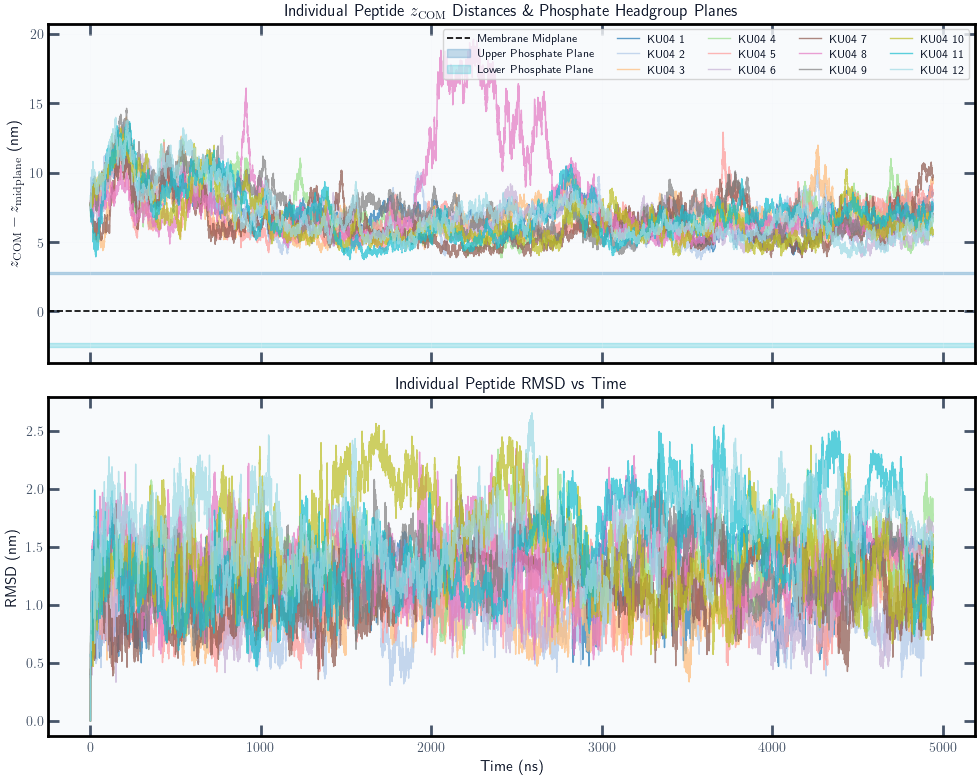

In [51]:
# ==========================================
# 5. CONVERT TO NANOMETERS & DATAFRAMES
# ==========================================

# Convert MDAnalysis Angstroms -> Nanometers (divide by 10)
z_peps_nm = z_peps_all / 10.0
z_mids_nm = z_mids_all / 10.0
z_pup_nm  = z_pup_all  / 10.0
z_plow_nm = z_plow_all / 10.0

# Calculate relative z-distances (nm)
# Distances from upper phosphate plane, lower phosphate plane, and midplane
dz_mid_nm   = z_peps_nm - z_mids_nm[:, np.newaxis]
dz_upper_nm = z_peps_nm - z_pup_nm[:, np.newaxis]
dz_lower_nm = z_peps_nm - z_plow_nm[:, np.newaxis]

# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_dz_mid = pd.DataFrame(dz_mid_nm, columns=pep_cols)
df_dz_mid.insert(0, "Time_ns", times)
df_dz_mid.to_csv("individual_peptide_z_midplane.csv", index=False)

df_dz_upper = pd.DataFrame(dz_upper_nm, columns=pep_cols)
df_dz_upper.insert(0, "Time_ns", times)
df_dz_upper.to_csv("individual_peptide_z_upper_phosphate.csv", index=False)

print("Saved CSV outputs to current working directory.")


# ==========================================
# 6. PUBLICATION-QUALITY PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, tight_layout=True)

# --- Plot 1: Peptide z-COM relative to Phosphate Planes ---
ax1.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Membrane Midplane")

# Plot upper and lower phosphate plane bands
avg_pup = (z_pup_nm - z_mids_nm).mean()
std_pup = (z_pup_nm - z_mids_nm).std()
avg_plow = (z_plow_nm - z_mids_nm).mean()
std_plow = (z_plow_nm - z_mids_nm).std()

ax1.axhspan(avg_pup - std_pup, avg_pup + std_pup, color="tab:blue", alpha=0.25, label="Upper Phosphate Plane")
ax1.axhspan(avg_plow - std_plow, avg_plow + std_plow, color="tab:cyan", alpha=0.25, label="Lower Phosphate Plane")

colors = plt.cm.tab20(np.linspace(0, 1, num_peptides))
for i in range(num_peptides):
    ax1.plot(times, dz_mid_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax1.set_ylabel(r"$z_{\mathrm{COM}} - z_{\mathrm{midplane}}$ (nm)")
ax1.set_title(r"Individual Peptide $z_{\mathrm{COM}}$ Distances \& Phosphate Headgroup Planes")
ax1.legend(ncol=5, loc="upper right", fontsize=8, frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Individual Peptide RMSD ---
for i in range(num_peptides):
    ax2.plot(times, rmsd_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax2.set_xlabel("Time (ns)")
ax2.set_ylabel("RMSD (nm)")
ax2.set_title("Individual Peptide RMSD vs Time")
#ax2.legend(ncol=4, loc="upper right", fontsize=8, frameon=True)

for ax in [ax1, ax2]:
    # Lengthen and thicken all major ticks
    ax.tick_params(axis='both', which='major', length=8, width=2)
    # thicken the figure border lines
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        # Color them black
        spine.set_edgecolor('black')
    ax.minorticks_off()

plt.savefig("individual_peptides_zcom_and_rmsd.svg", dpi=300)
plt.show()

Nope. No evidence of translocation at all. Not even with multiple peptides.

Now, checking for contacts with prolint

In [40]:
from prolint import Universe, setup_logging
import logging

# Enable logging to see progress
setup_logging(level=logging.INFO)

# Load simulation
universe = Universe(top_file, traj_file)

# Check what was loaded
print(f"Trajectory: {universe.trajectory.n_frames} frames")
print(f"Query atoms: {universe.query.n_atoms} (protein)")
print(f"Database atoms: {universe.database.n_atoms} (non-protein)")

2026-08-01 22:28:08,583 - prolint.core.universe - INFO - Loading topology: simulation_cg_multipeptide/traj_dry.tpr
2026-08-01 22:28:08,584 - prolint.core.universe - INFO - Loading trajectory: simulation_cg_multipeptide/traj_dry.xtc


2026-08-01 22:28:08,732 - prolint.core.universe - INFO - Query selection: 'protein' (984 atoms)
2026-08-01 22:28:08,736 - prolint.core.universe - INFO - Database selection: 'not protein' (6073 atoms)
2026-08-01 22:28:08,752 - prolint.core.universe - INFO - Universe loaded: 24714 frames, 7057 atoms, 928 residues


Trajectory: 24714 frames
Query atoms: 984 (protein)
Database atoms: 6073 (non-protein)


Since there are 12 replicas of the peptide here:

In [24]:
from prolint.core.replica_detection import detect_replicas

# Check for replicas in your system
result = detect_replicas(universe.query)
print(f"Found {result.n_replicas} replicas")
for info in result.replica_info:
    print(f"  Replica {info.replica_id}: {info.n_residues} residues")

2026-08-01 22:08:18,844 - prolint.core.replica_detection - INFO - Detected 12 replicas by bond connectivity


Found 12 replicas
  Replica A: 36 residues
  Replica B: 36 residues
  Replica C: 36 residues
  Replica D: 36 residues
  Replica E: 36 residues
  Replica F: 36 residues
  Replica G: 36 residues
  Replica H: 36 residues
  Replica I: 36 residues
  Replica J: 36 residues
  Replica K: 36 residues
  Replica L: 36 residues


In [41]:
# Analyze only the phosphates of lipids in a membrane model
universe.database = universe.select_atoms(phos_sel)

print("Computing contacts for all peptides")
contacts_allp = universe.compute_contacts(cutoff=7.0)
# Run analysis
result_allp = contacts_allp.analyze("timeseries")


2026-08-01 22:28:15,633 - prolint.core.replica_detection - INFO - Detected 12 replicas by bond connectivity
2026-08-01 22:28:15,635 - prolint.core.universe - INFO - Analyzing 12 replicas with unique residue IDs


2026-08-01 22:28:15,653 - prolint.computers.contacts - INFO - Computing contacts: cutoff=7.0 Å, frames=24714


Computing contacts for all peptides


  0%|          | 0/24714 [00:00<?, ?it/s]

2026-08-01 22:28:24,642 - prolint.computers.contacts - INFO - Frame progress: 2472/24714 (10%)
2026-08-01 22:28:33,862 - prolint.computers.contacts - INFO - Frame progress: 4943/24714 (20%)
2026-08-01 22:28:43,397 - prolint.computers.contacts - INFO - Frame progress: 7415/24714 (30%)
2026-08-01 22:28:53,538 - prolint.computers.contacts - INFO - Frame progress: 9886/24714 (40%)
2026-08-01 22:29:05,136 - prolint.computers.contacts - INFO - Frame progress: 12357/24714 (50%)
2026-08-01 22:29:16,487 - prolint.computers.contacts - INFO - Frame progress: 14829/24714 (60%)
2026-08-01 22:29:26,108 - prolint.computers.contacts - INFO - Frame progress: 17300/24714 (70%)
2026-08-01 22:29:35,764 - prolint.computers.contacts - INFO - Frame progress: 19772/24714 (80%)
2026-08-01 22:29:46,825 - prolint.computers.contacts - INFO - Frame progress: 22243/24714 (90%)
2026-08-01 22:29:58,102 - prolint.computers.contacts - INFO - Frame progress: 24714/24714 (100%)
2026-08-01 22:29:58,109 - prolint.computers

In [92]:
times_mus = np.array([ts.time/1e6 for ts in universe.trajectory])

In [93]:
times_mus[-1]

4.9426

visualize where phosphate headgroup molecules (database) preferentially locate around the peptides.

The peptide (query)

Computes the 2D spatial distribution of database molecule positions relative to the query center of mass (in red) over trajectory frames.

In [154]:
# Compute 2D density map
result_rhomap = contacts_allp.analyze(
    "density_map",
    bins=50,                      # Resolution
    frame_start=0,
    frame_end=None,               # All frames
    frame_step=1
)

2026-08-02 01:37:51,879 - prolint.analysis.density - INFO - Computing density map: 24714 frames, 50 bins


### Single Peptide-membrane

In [ ]:
sp_topol_file = "simulation_cg_notrans/md_extend.tpr"
sp_traj_file = "simulation_cg_notrans/traj_nojump.xtc"


# Load simulation
u_sp = Universe(sp_topol_file, sp_traj_file)

# Check what was loaded
print(f"Trajectory: {u_sp.trajectory.n_frames} frames")
print(f"Query atoms: {u_sp.query.n_atoms} (protein)")
print(f"Database atoms: {u_sp.database.n_atoms} (non-protein)")

2026-08-02 01:23:38,206 - prolint.core.universe - INFO - Loading topology: simulation_cg_notrans/md_extend.tpr
2026-08-02 01:23:38,207 - prolint.core.universe - INFO - Loading trajectory: simulation_cg_notrans/traj_nojump.xtc
2026-08-02 01:24:02,765 - prolint.core.universe - INFO - Query selection: 'protein' (82 atoms)
2026-08-02 01:24:02,767 - prolint.core.universe - INFO - Database selection: 'not protein' (16096 atoms)
2026-08-02 01:24:02,812 - prolint.core.universe - INFO - Universe loaded: 15001 frames, 16178 atoms, 9026 residues


Trajectory: 15001 frames
Query atoms: 82 (protein)
Database atoms: 16096 (non-protein)


In [ ]:
# Analyze only the phosphates of lipids in a membrane model
u_sp.database = u_sp.select_atoms(phos_sel)

print("Computing contacts for all peptides")
contacts_sp = u_sp.compute_contacts(cutoff=7.0)
# Run analysis


2026-08-02 01:27:07,302 - prolint.computers.contacts - INFO - Computing contacts: cutoff=7.0 Å, frames=15001


Computing contacts for all peptides


  0%|          | 0/15001 [00:00<?, ?it/s]

2026-08-02 01:27:11,327 - prolint.computers.contacts - INFO - Frame progress: 1501/15001 (10%)
2026-08-02 01:27:14,955 - prolint.computers.contacts - INFO - Frame progress: 3001/15001 (20%)
2026-08-02 01:27:18,471 - prolint.computers.contacts - INFO - Frame progress: 4501/15001 (30%)
2026-08-02 01:27:22,112 - prolint.computers.contacts - INFO - Frame progress: 6001/15001 (40%)
2026-08-02 01:27:25,740 - prolint.computers.contacts - INFO - Frame progress: 7501/15001 (50%)
2026-08-02 01:27:29,758 - prolint.computers.contacts - INFO - Frame progress: 9001/15001 (60%)
2026-08-02 01:27:34,745 - prolint.computers.contacts - INFO - Frame progress: 10501/15001 (70%)
2026-08-02 01:27:39,513 - prolint.computers.contacts - INFO - Frame progress: 12001/15001 (80%)
2026-08-02 01:27:45,140 - prolint.computers.contacts - INFO - Frame progress: 13501/15001 (90%)
2026-08-02 01:27:50,987 - prolint.computers.contacts - INFO - Frame progress: 15001/15001 (100%)
2026-08-02 01:27:50,991 - prolint.computers.c

In [155]:
# Compute 2D density map
result_rhomap_sp = contacts_sp.analyze(
    "density_map",
    bins=50,                      # Resolution
    frame_start=0,
    frame_end=None,               # All frames
    frame_step=1
)

2026-08-02 01:38:50,706 - prolint.analysis.density - INFO - Computing density map: 15001 frames, 50 bins


### Plot all results

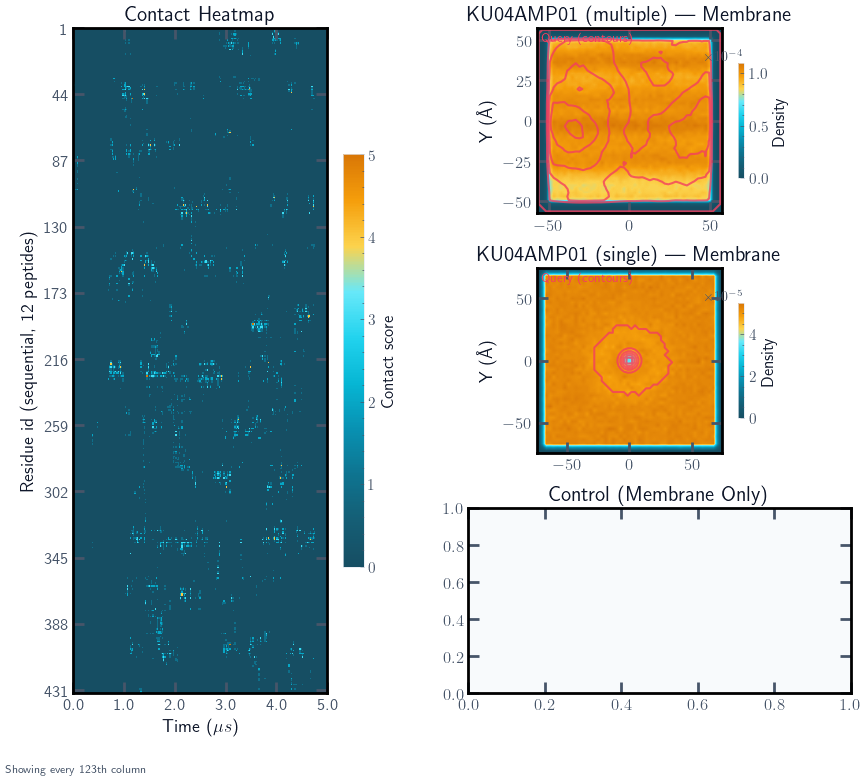

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from prolint.plotting import plot
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(9, 8))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1], width_ratios=[1, 1])

# Left column: contact heatmap
ax0 = fig.add_subplot(gs[0:3, 0])
plot("heatmap", result_allp, colorscheme="prolint", ax=ax0)

img0 = ax0.images[0]
data = img0.get_array()

target_max_us = 5.0
n_cols = data.shape[1]

# Map the heatmap columns to the actual time points
if len(times_mus) >= n_cols:
    frame_idx = np.linspace(0, len(times_mus) - 1, n_cols).round().astype(int)
    mapped_times = times_mus[frame_idx]
else:
    mapped_times = np.linspace(0, times_mus[-1], n_cols)

# Add only a small zero-padding region at the end
pad_len = max(1, int(0.05 * n_cols))  # ~5% of width
padded_data = np.pad(data, ((0, 0), (0, pad_len)), mode="constant", constant_values=0)

img0.set_data(padded_data)
img0.set_extent([0, target_max_us, padded_data.shape[0], 0])

ax0.set_xlim(0, target_max_us)
tick_positions = np.linspace(0, target_max_us, 6)
ax0.set_xticks(tick_positions)
ax0.set_xticklabels([f"{t:.1f}" for t in tick_positions])

ax0.set_xlabel(r"Time ($\mu s$)", fontsize=13)
ax0.set_ylabel("Residue id (sequential, 12 peptides)", fontsize=13)
ax0.set_title("Contact Heatmap", fontsize=15)


cbar0 = fig.colorbar(img0, ax=ax0, shrink=0.62)
cbar0.ax.tick_params(labelsize=11)
cbar0.set_label("Contact score", fontsize=12)


# Right column: current density map
ax1 = fig.add_subplot(gs[0, 1])

# Visualize with query outline
plot(
    "density_map",
    result_rhomap,
    show_query_contours=True,     # Show query position
    colorscheme="prolint",
    ax=ax1
)
ax1.set_title("KU04AMP01 (multiple) --- Membrane", fontsize=15)
ax1.set_xlabel(None)  # Hide x-labels for top plots

img1 = ax1.images[0]
cbar1 = fig.colorbar(img1, ax=ax1, shrink=0.62)
cbar1.ax.tick_params(labelsize=11)
cbar1.set_label("Density", fontsize=12)


# Lower-right slot: placeholder for control density map
ax2 = fig.add_subplot(gs[1, 1])
plot(
    "density_map",
    result_rhomap_sp,
    show_query_contours=True,     # Show query position
    colorscheme="prolint",
    ax=ax2
)
ax2.set_title("KU04AMP01 (single) --- Membrane", fontsize=15)
ax2.set_xlabel(None)  # Hide x-labels for middle plots
img2 = ax2.images[0]
cbar2 = fig.colorbar(img2, ax=ax2, shrink=0.62)
cbar2.ax.tick_params(labelsize=11)
cbar2.set_label("Density", fontsize=12)



ax3 = fig.add_subplot(gs[2, 1])
## ADD CODE FOR CONTROL MEMBRANE ONLY PLOT
ax3.set_title("Control (Membrane Only)", fontsize=15)

for ax in [ax0, ax1, ax2, ax3]:
    ax.xaxis.label.set_size(13)
    ax.yaxis.label.set_size(13)
    ax.tick_params(axis="both", which="major", length=8, width=2, labelsize=12)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")
    ax.minorticks_off()

# Remove only the extra axes created by the plotting helpers
for extra_ax in list(fig.axes):
    if extra_ax not in {ax0, ax1, ax2, ax3, cbar0.ax, cbar1.ax, cbar2.ax}:
        fig.delaxes(extra_ax)

from matplotlib.ticker import ScalarFormatter

for cbar in [cbar0, cbar1, cbar2]:
    cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    cbar.ax.yaxis.get_major_formatter().set_scientific(True)
    cbar.ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
#fig.savefig("ku04amp-multi-membrane-bilayer-cg-PP.svg", dpi=300)

There is some evidence of membrane disruption, which might cause translocation eventually, but multiple peptides are needed.

See the undulations in the membrane density for the multipeptide case? I saw those in the vmd visualization also.


# TODO : Do the Density Map for the control experiment (no query)

Put them side by side and compare. If the undulations are absent in the control, then we have proof that there is some weak membrane disruption over simulation time scales.

Read:
https://prolint2.readthedocs.io/en/latest/tutorials/analysis-types.html

# TODO: HOLE analysis
In a cell, download the HOLE program and install it in `temp`.